<h1><center><strong> KMeans

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer

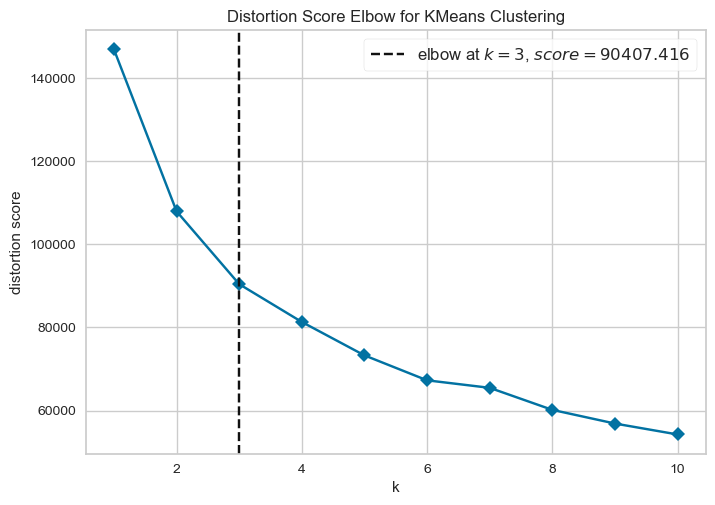

In [2]:
data_path = '../../../../data/processed_data/main_datasets/customer_data_processed.csv'
data = pd.read_csv(data_path)

X = data.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(1, 11), timings=False)
visualizer.fit(X_scaled)
visualizer.show();

Как мы видим, точка в которой происходит значительное снижение скорости уменьшения inertia находится при количестве кластеров равном 3

In [3]:
n_clusters = visualizer.elbow_value_

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(X_scaled)

data['Cluster'] = kmeans.labels_

In [4]:
output_path = '../../../../data/processed_data/train_models_data/data_without_PCA/data_without_generated_features/KMeans_default.csv'
data.to_csv(output_path, index=False)

Определим центры кластеров, чтобы понять различия между данными кластерами

In [5]:
centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=data.columns[:-1])
centers

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,0.438527,0.400334,0.809609,0.833262,0.636718,-0.111748,0.822157,0.885517,0.579942,-0.113091,-0.101898,0.927714,0.392796,0.564971,0.376030,-0.017305,0.192220
1,-1.008508,-0.585474,0.248538,-0.309783,0.252250,-0.833428,0.195179,-0.401367,0.247259,-0.677520,-0.751790,0.072211,-0.373831,-0.632808,-0.769491,0.439610,-0.090970
2,0.545902,0.153625,-1.162615,-0.614917,-0.972743,0.982320,-1.121796,-0.579270,-0.904003,0.823483,0.887324,-1.113588,-0.055590,0.017862,0.370103,-0.432724,-0.121788
